# EDA
- Andreas
blandade tester på vår data


# SETUPS
- Imports
- Setups

In [204]:
import pandas as pd
import duckdb
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [205]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
})

STAD_FARGER = {
    'Stockholm': '#2E86AB',
    'Malmö':     '#3BB273', 
    'Göteborg':  '#E84855',
}

print('BOOOOM')

BOOOOM


# LADDA IN DATAN (DUCKDB)

In [206]:
df_bostader  = pd.read_csv('../ETL_Pipline/bostader.csv')
df_priser    = pd.read_csv('../ETL_Pipline/priser.csv')
df_platser   = pd.read_csv('../ETL_Pipline/platser.csv')
df_visningar = pd.read_csv('../ETL_Pipline/visningar.csv')

con = duckdb.connect()
con.register('bostader',  df_bostader)
con.register('priser',    df_priser)
con.register('platser',   df_platser)
con.register('visningar', df_visningar)

print('TABELLER:')
print(f'  platser:   {len(df_platser)} RADER')
print(f'  bostader:  {len(df_bostader)} RADER')
print(f'  priser:    {len(df_priser)} RADER')
print(f'  visningar: {len(df_visningar)} RADER')

TABELLER:
  platser:   20 RADER
  bostader:  1000 RADER
  priser:    1000 RADER
  visningar: 2 RADER


# JOIN TABLES DUCKDB

In [207]:
query = """
    SELECT *
    FROM bostader b
    JOIN priser    p  ON b.id       = p.bostad_id
    JOIN platser   pl ON b.plats_id = pl.plats_id
"""

df = con.execute(query).df()
df['created_at'] = pd.to_datetime(df['created_at'])

print(f'Sammansatt tabell: {df.shape[0]} rader, {df.shape[1]} kolumner')
df.head()

Sammansatt tabell: 1000 rader, 31 kolumner


,id,typ,upplåtelseform,rum,boyta,boyta_enhet,tillgänglig,created_at,adress,lat,...,pris,avgift,kvadratmeterpris,pris_per_kvm,valuta,manadskostnad,område,stad,plats_id_1,kommun_befolkning
0,1,hus,köpa,5,120,m²,True,2026-01-04,Bergsgatan 36,59.31848,...,10587543,3293,88229,88230.0,SEK,52039,Södermalm,Stockholm,1,995574
1,2,lägenhet,köpa,6,144,m²,True,2025-05-24,Parkvägen 78,55.56498,...,4447103,9411,30882,30883.0,SEK,29886,Hyllie,Malmö,2,365644
2,3,lägenhet,köpa,4,96,m²,False,2025-11-06,Kungsgatan 81,55.59328,...,2203192,5059,22949,22950.0,SEK,15202,Rosengård,Malmö,3,365644
3,4,lägenhet,köpa,4,76,m²,False,2025-05-30,Lindvägen 66,59.34106,...,7325734,4756,96391,96391.0,SEK,38484,Vasastan,Stockholm,4,995574
4,5,lägenhet,köpa,3,78,m²,True,2025-10-12,Skolvägen 117,59.31236,...,6662306,5594,85414,85414.0,SEK,36268,Nacka,Stockholm,5,995574


# TESTER

In [208]:
# Kvalitetstest av datan
print('=== Datatyper & null-värden ===')
print(df.info())

=== Datatyper & null-värden ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     1000 non-null   int64         
 1   typ                    1000 non-null   object        
 2   upplåtelseform         1000 non-null   object        
 3   rum                    1000 non-null   int64         
 4   boyta                  1000 non-null   int64         
 5   boyta_enhet            1000 non-null   object        
 6   tillgänglig            1000 non-null   bool          
 7   created_at             1000 non-null   datetime64[ns]
 8   adress                 1000 non-null   object        
 9   lat                    1000 non-null   float64       
 10  lon                    1000 non-null   float64       
 11  plats_id               1000 non-null   int64         
 12  sparad                 1000 non

In [209]:
print("\n--- YTA / BOYTA ---")
print(f"Störst: {df['boyta'].max()} kvm")
print(f"Minst: {df['boyta'].min()} kvm")
print(f"Medel: {df['boyta'].mean():.0f} kvm")


--- YTA / BOYTA ---
Störst: 168 kvm
Minst: 18 kvm
Medel: 81 kvm


In [210]:
display(df[['pris', 'avgift', 'rum', 'boyta', 'pris_per_kvm']].describe().round(0))

,pris,avgift,rum,boyta,pris_per_kvm
count,1000.0,1000.0,1000.0,1000.0,1000.0
mean,3608014.0,2846.0,4.0,81.0,44760.0
std,3506959.0,2365.0,2.0,40.0,33406.0
min,2329.0,0.0,1.0,18.0,120.0
25%,656893.0,1097.0,2.0,48.0,21584.0
50%,2877566.0,2648.0,3.0,80.0,44502.0
75%,5364515.0,3972.0,5.0,112.0,63016.0
max,19868269.0,12345.0,6.0,168.0,142574.0


In [211]:
print(df_priser.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bostad_id         1000 non-null   int64  
 1   pris              1000 non-null   int64  
 2   avgift            1000 non-null   int64  
 3   kvadratmeterpris  1000 non-null   int64  
 4   pris_per_kvm      1000 non-null   float64
 5   valuta            1000 non-null   object 
 6   manadskostnad     1000 non-null   int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 54.8+ KB
None


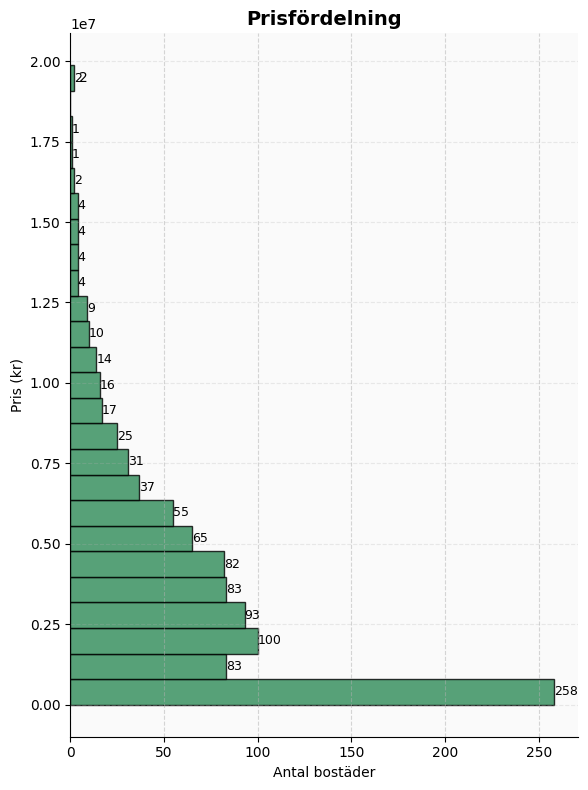

In [212]:
plt.figure(figsize=(6,8))

counts, bins, patches = plt.hist(
    df['pris'],
    bins=25,
    orientation='horizontal',
    color='seagreen',
    edgecolor='black',
    alpha=0.8
)

for count, patch in zip(counts, patches):
    y = patch.get_y() + patch.get_height() / 2
    x = count
    
    if count > 0:  
        plt.text(x, y, f'{int(count)}',
                 va='center', ha='left', fontsize=9)

plt.title('Prisfördelning', fontsize=14, fontweight='bold')
plt.xlabel('Antal bostäder')
plt.ylabel('Pris (kr)')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.text(x + max(counts)*0.01, y, f'{int(count)}', va='center')

plt.tight_layout()
plt.show()

In [213]:
df_clean = con.execute("""
    SELECT * FROM df
    WHERE pris_per_kvm BETWEEN 5000 AND 120000
    AND boyta >= 20
""").df()

print(f'Rader efter filtrering: {len(df_clean)} (borttagna: {len(df) - len(df_clean)})')

Rader efter filtrering: 725 (borttagna: 275)


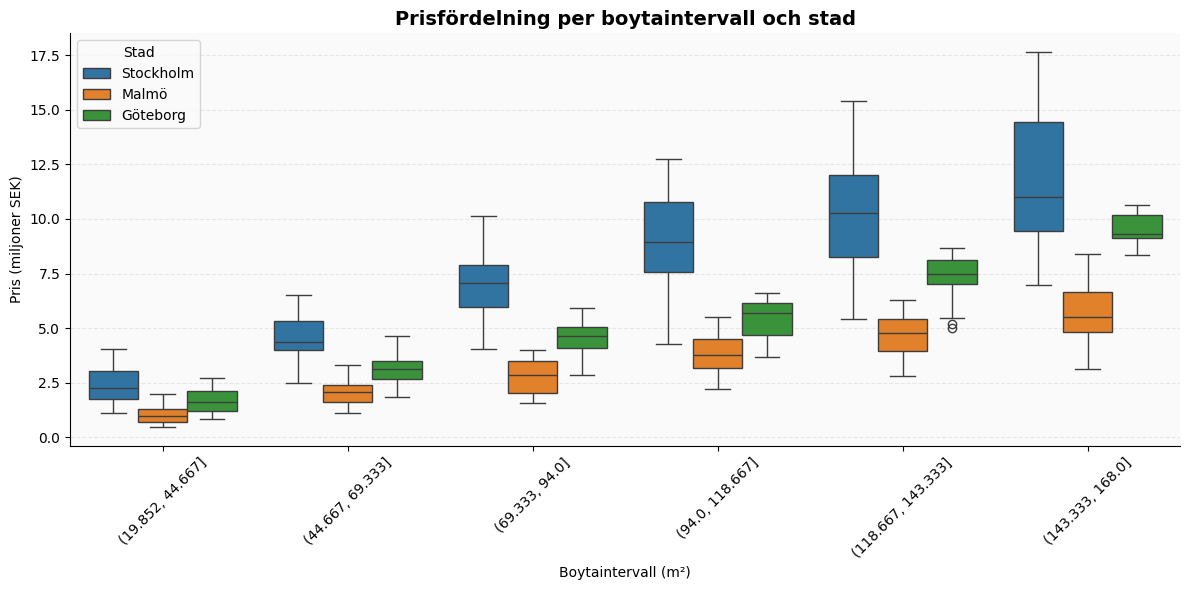

In [214]:
df_plot = df_clean.copy()
df_plot['pris_miljoner'] = df_plot['pris'] / 1_000_000

df_plot['boyta_bin'] = pd.cut(df_plot['boyta'], bins=6)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_plot,
    x='boyta_bin',
    y='pris_miljoner',
    hue='stad'
)

plt.title("Prisfördelning per boytaintervall och stad", fontsize=14, fontweight='bold')
plt.xlabel("Boytaintervall (m²)")
plt.ylabel("Pris (miljoner SEK)")
plt.xticks(rotation=45)

plt.legend(title="Stad")

plt.tight_layout()
plt.show()

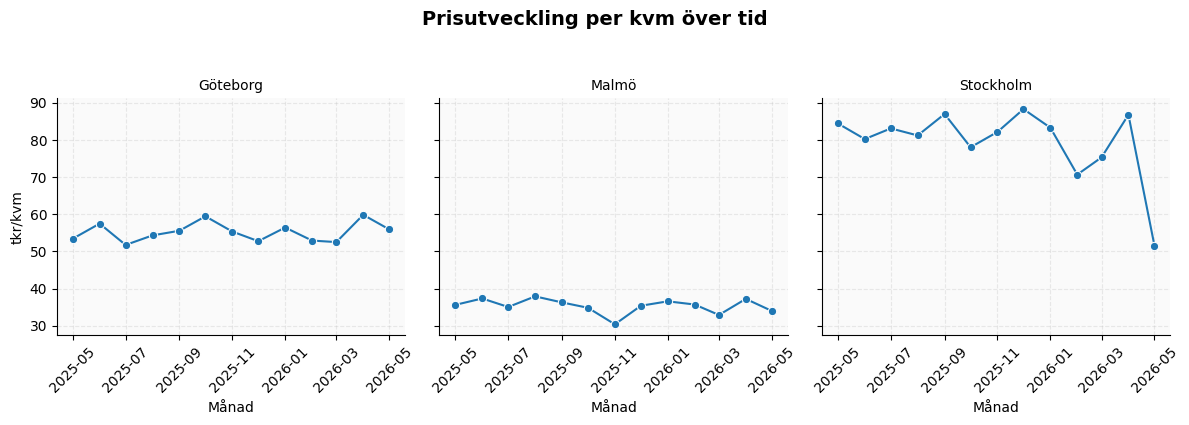

In [215]:
df_trend = df_clean.copy()
df_trend['created_at'] = pd.to_datetime(df_trend['created_at'])
df_trend['månad'] = df_trend['created_at'].dt.to_period('M')

trend = (
    df_trend
    .groupby(['månad', 'stad'])['pris_per_kvm']
    .mean()
    .reset_index()
)

trend['månad_dt'] = trend['månad'].dt.to_timestamp()
trend['pris_k'] = trend['pris_per_kvm'] / 1000

g = sns.FacetGrid(trend, col="stad", col_wrap=3, height=4, sharey=True)

g.map_dataframe(
    sns.lineplot,
    x="månad_dt",
    y="pris_k",
    marker="o"
)

g.set_axis_labels("Månad", "tkr/kvm")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Prisutveckling per kvm över tid", y=1.05, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

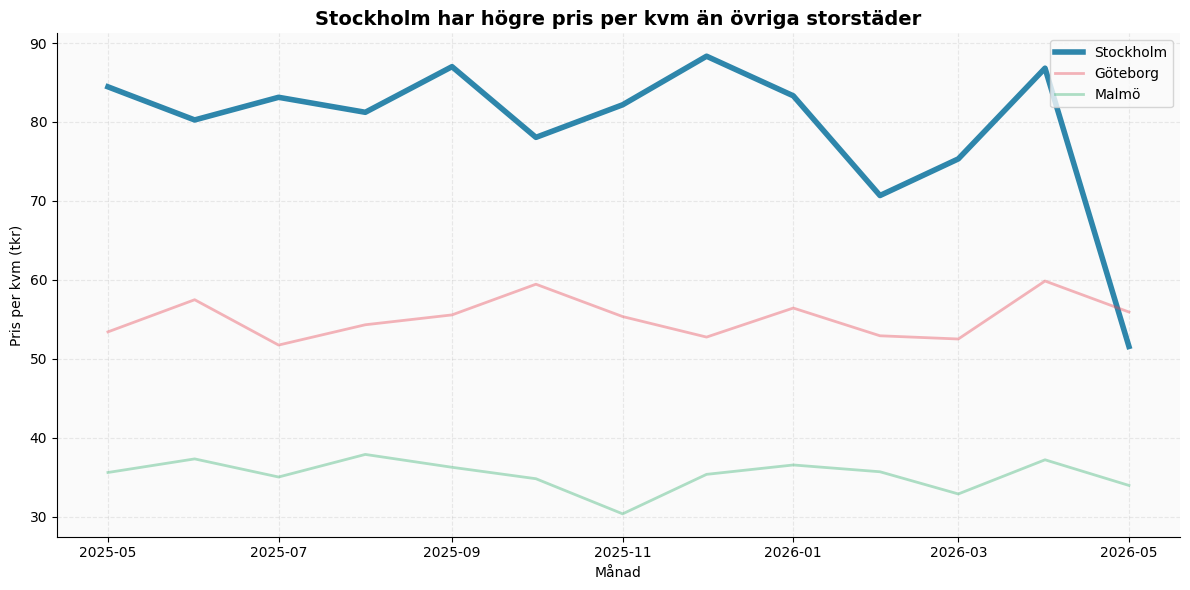

In [216]:
story_df = df_clean.copy()

story_df['created_at'] = pd.to_datetime(story_df['created_at'])
story_df['månad'] = story_df['created_at'].dt.to_period('M')

trend_story = (
    story_df
    .groupby(['månad', 'stad'])['pris_per_kvm']
    .mean()
    .reset_index()
)

trend_story['månad'] = trend_story['månad'].dt.to_timestamp()
trend_story['pris_kvm'] = trend_story['pris_per_kvm'] / 1000

plt.figure(figsize=(12,6))

for stad in ['Stockholm', 'Göteborg', 'Malmö']:

    temp = trend_story[trend_story['stad'] == stad]

    # Gör Stockholm tydligare
    if stad == 'Stockholm':
        plt.plot(
            temp['månad'],
            temp['pris_kvm'],
            label=stad,
            linewidth=4,
            color=STAD_FARGER[stad]
        )

    else:
        plt.plot(
            temp['månad'],
            temp['pris_kvm'],
            label=stad,
            linewidth=2,
            alpha=0.4,
            color=STAD_FARGER[stad]
        )

plt.title(
    'Stockholm har högre pris per kvm än övriga storstäder',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Månad')
plt.ylabel('Pris per kvm (tkr)')

plt.legend()

plt.tight_layout()
plt.show()

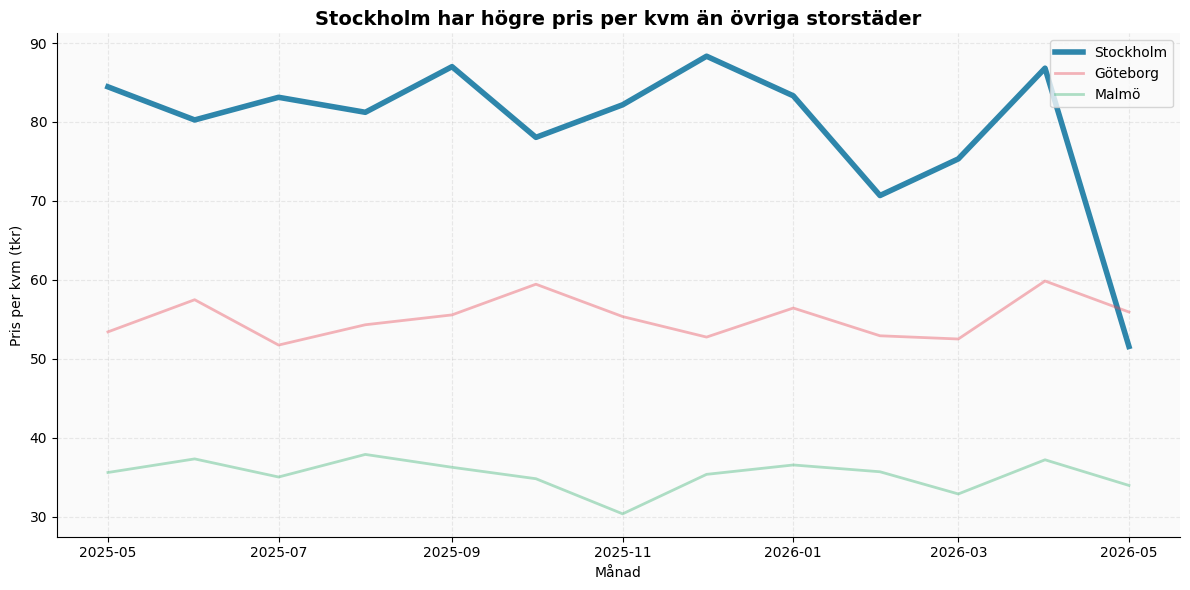

In [217]:
story_df = df_clean.copy()

story_df['created_at'] = pd.to_datetime(story_df['created_at'])
story_df['månad'] = story_df['created_at'].dt.to_period('M')

trend_story = (
    story_df
    .groupby(['månad', 'stad'])['pris_per_kvm']
    .mean()
    .reset_index()
)

trend_story['månad'] = trend_story['månad'].dt.to_timestamp()
trend_story['pris_kvm'] = trend_story['pris_per_kvm'] / 1000

plt.figure(figsize=(12,6))

for stad in ['Stockholm', 'Göteborg', 'Malmö']:

    temp = trend_story[trend_story['stad'] == stad]

    # Gör Stockholm tydligare
    if stad == 'Stockholm':
        plt.plot(
            temp['månad'],
            temp['pris_kvm'],
            label=stad,
            linewidth=4,
            color=STAD_FARGER[stad]
        )

    else:
        plt.plot(
            temp['månad'],
            temp['pris_kvm'],
            label=stad,
            linewidth=2,
            alpha=0.4,
            color=STAD_FARGER[stad]
        )

plt.title(
    'Stockholm har högre pris per kvm än övriga storstäder',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Månad')
plt.ylabel('Pris per kvm (tkr)')

plt.legend()

plt.tight_layout()
plt.show()

# DATA STORYTELLING GRAFER

## GRAF 1
- # BOSTADPRIS PER KVADRATMETER

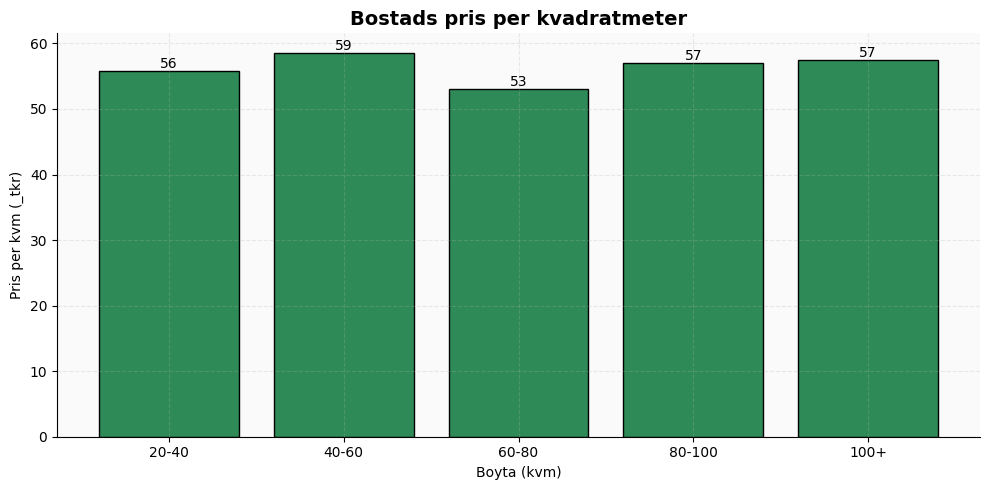

In [218]:
yta_story = df_clean.copy()

yta_story['yta_grupp'] = pd.cut(
    yta_story['boyta'],
    bins=[20, 40, 60, 80, 100, 200],
    labels=['20-40', '40-60', '60-80', '80-100', '100+']
)

yta_trend = (
    yta_story
    .groupby('yta_grupp', observed=False)['pris_per_kvm']
    .mean()
)

plt.figure(figsize=(10,5))

bars = plt.bar(
    yta_trend.index.astype(str),
    yta_trend.values / 1000,
    color='seagreen',
    edgecolor='black'
)

plt.title(
    'Bostads pris per kvadratmeter',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Boyta (kvm)')
plt.ylabel('Pris per kvm (_tkr)')

for bar in bars:
    h = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f'{h:.0f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

# GRAF 1 - SAMMANFATTNING
- #  Mindre bostäder har generellt ett högre pris per kvadratmeter än större bostäder.

## GRAF 2
# Vilken storstad har högst priser per kvm?

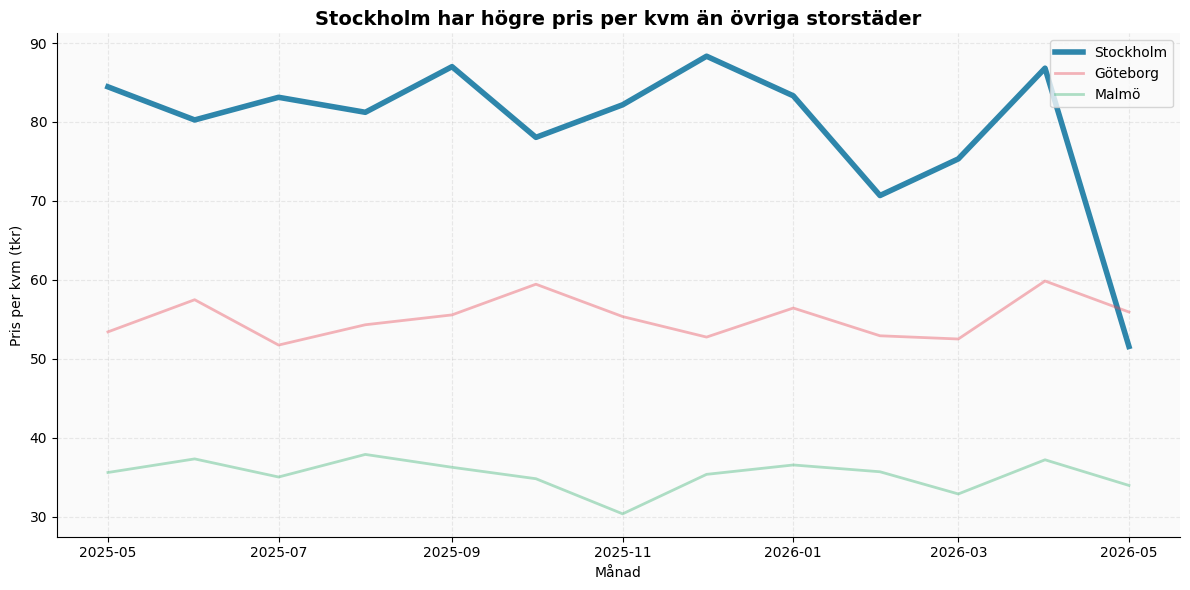

In [219]:
story_df = df_clean.copy()

story_df['created_at'] = pd.to_datetime(story_df['created_at'])
story_df['månad'] = story_df['created_at'].dt.to_period('M')

trend_story = (
    story_df
    .groupby(['månad', 'stad'])['pris_per_kvm']
    .mean()
    .reset_index()
)

trend_story['månad'] = trend_story['månad'].dt.to_timestamp()
trend_story['pris_kvm'] = trend_story['pris_per_kvm'] / 1000

plt.figure(figsize=(12,6))

for stad in ['Stockholm', 'Göteborg', 'Malmö']:

    temp = trend_story[trend_story['stad'] == stad]

    if stad == 'Stockholm':
        plt.plot(
            temp['månad'],
            temp['pris_kvm'],
            label=stad,
            linewidth=4,
            color=STAD_FARGER[stad]
        )

    else:
        plt.plot(
            temp['månad'],
            temp['pris_kvm'],
            label=stad,
            linewidth=2,
            alpha=0.4,
            color=STAD_FARGER[stad]
        )

plt.title(
    'Stockholm har högre pris per kvm än övriga storstäder',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Månad')
plt.ylabel('Pris per kvm (tkr)')

plt.legend()

plt.tight_layout()
plt.show()

## GRAF 2 - SAMMANFATTNING
- # Stockholm har tydligt högre genomsnittliga bostadspriser än Göteborg och Malmö.

## GRAF 3 
- # Prisutveckligen över tid (kvm) mellan storstäderna

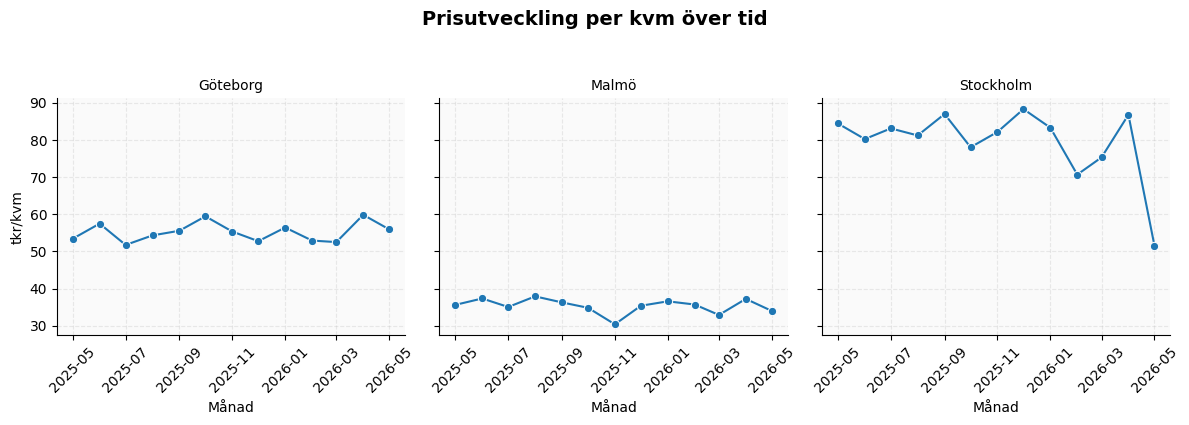

In [220]:
df_trend = df_clean.copy()
df_trend['created_at'] = pd.to_datetime(df_trend['created_at'])
df_trend['månad'] = df_trend['created_at'].dt.to_period('M')

trend = (
    df_trend
    .groupby(['månad', 'stad'])['pris_per_kvm']
    .mean()
    .reset_index()
)

trend['månad_dt'] = trend['månad'].dt.to_timestamp()
trend['pris_k'] = trend['pris_per_kvm'] / 1000

g = sns.FacetGrid(trend, col="stad", col_wrap=3, height=4, sharey=True)

g.map_dataframe(
    sns.lineplot,
    x="månad_dt",
    y="pris_k",
    marker="o"
)

g.set_axis_labels("Månad", "tkr/kvm")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Prisutveckling per kvm över tid", y=1.05, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## GRAF 3 SAMMANFATTNING
- # Prisutveckligen över tid ligger både högre och stabilare hos Stockholm jämfört med Malmö och Göteborg

## GRAF 4
- # Vilken stad har störst andel dyra bostäder?

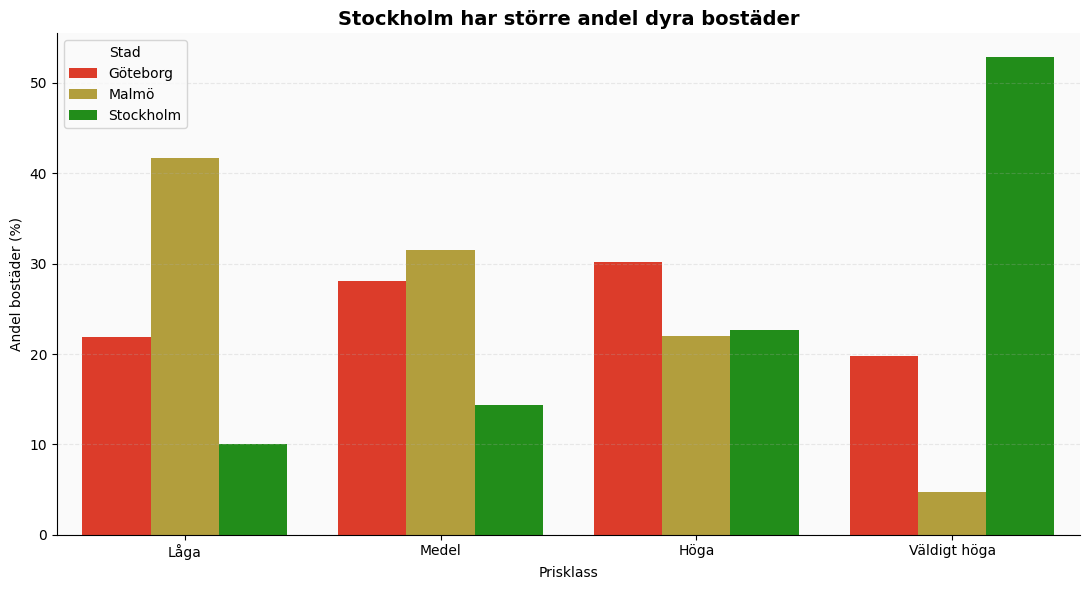

In [221]:
STAD_FARGER = {
    'Stockholm':"#12A007",
    'Malmö': "#C5AB2A",
    'Göteborg': "#F9240D",
}
story_df = df_clean.copy()

story_df['prisklass'] = pd.qcut(
    story_df['pris'],
    q=4,
    labels=['Låga', 'Medel', 'Höga', 'Väldigt höga']
)

andelar = (
    story_df
    .groupby(['stad', 'prisklass'], observed=False)
    .size()
    .reset_index(name='antal')
)

andelar['procent'] = (
    andelar.groupby('stad')['antal']
    .transform(lambda x: x / x.sum() * 100)
)

plt.figure(figsize=(11,6))

sns.barplot(
    data=andelar,
    x='prisklass',
    y='procent',
    hue='stad',
    palette=STAD_FARGER
)

plt.title(
    'Stockholm har större andel dyra bostäder',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Prisklass')
plt.ylabel('Andel bostäder (%)')

plt.legend(title='Stad')

plt.tight_layout()
plt.show()

# GRAF 4 - SAMMANFATTNING
- # Grafen visar att Stockholm har större andel bostäder i de högre prisklasserna jämfört med Göteborg och Malmö.



# SAMMANFATTNING AV ALLA GRAFERNA I DEN HÄR DATA-storytelling
- # Leder Stockholm prismässigt per kvm
- # Stockholm har ett större genomsnitt på bostadspriser
- # Prisutveckligen över tid ligger både högre och stabilare hos Stockholm jämfört med Malmö och Göteborg
- # Det större andelen bostäder i stockholm ligger i de högre prisklasserna jämfört med andra storstäder